<a href="https://colab.research.google.com/github/duaa-abdul/catVsdog_classification/blob/main/CatvsDog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
import kagglehub

# Download latest version
df= kagglehub.dataset_download("samuelcortinhas/cats-and-dogs-image-classification")

print("Path to dataset files:", df)

100%|██████████| 64.4M/64.4M [00:00<00:00, 141MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/samuelcortinhas/cats-and-dogs-image-classification/versions/4


### Visualize some images



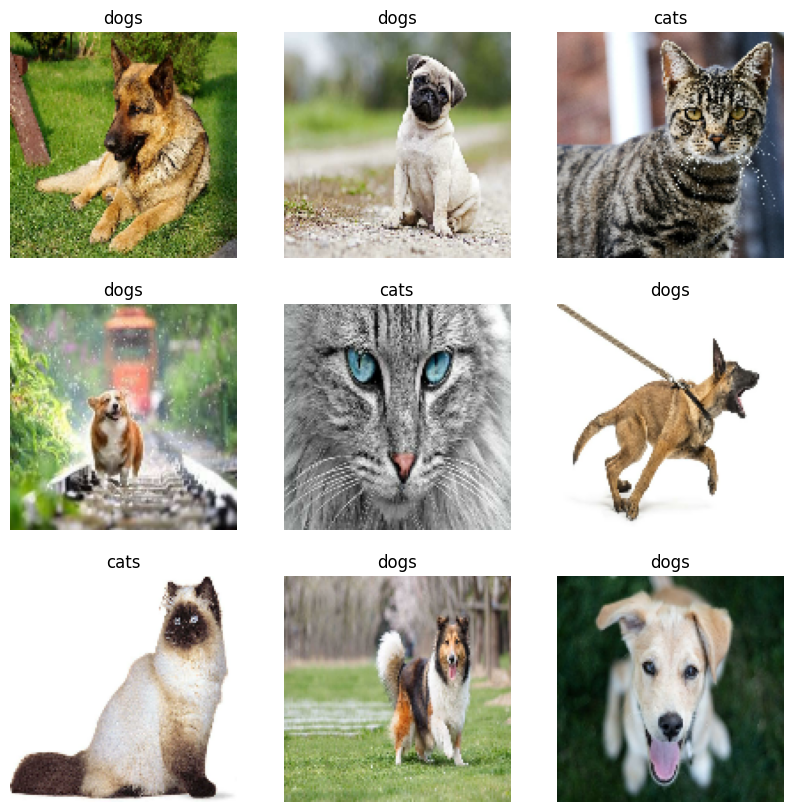

In [15]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Scale the images back to 0-255 before converting to uint8 for display
        plt.imshow((images[i].numpy() * 255).astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

### Build the Deep Learning Model



In [11]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(class_names), activation='softmax') # Output layer for 2 classes (cats/dogs)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model



In [12]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### Train the Model



In [13]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 696ms/step - accuracy: 0.4883 - loss: 0.8118 - val_accuracy: 0.4929 - val_loss: 0.6935
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 594ms/step - accuracy: 0.5296 - loss: 0.6902 - val_accuracy: 0.5143 - val_loss: 0.6905
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 591ms/step - accuracy: 0.6086 - loss: 0.6720 - val_accuracy: 0.5286 - val_loss: 0.6960
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 598ms/step - accuracy: 0.6750 - loss: 0.6208 - val_accuracy: 0.5714 - val_loss: 0.6919
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 609ms/step - accuracy: 0.7307 - loss: 0.5520 - val_accuracy: 0.6071 - val_loss: 0.7208
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 565ms/step - accuracy: 0.7864 - loss: 0.4554 - val_accuracy: 0.5500 - val_loss: 0.7657
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 610ms/step - accuracy: 0.8402 - loss: 0.3727 - val_accuracy: 0.6571 - val_loss: 0.7660
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 591ms/step - accuracy: 0.8384 - loss: 0.3708 - val_accu

### Evaluate Model Performance


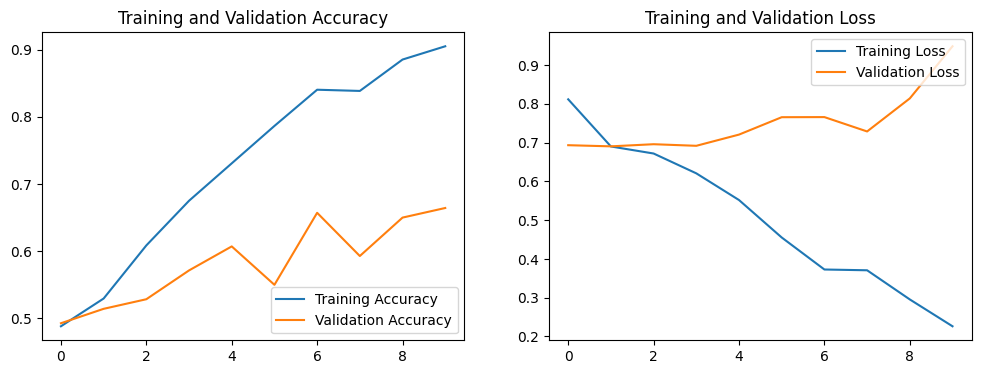

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()